In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\devso\causal-ml-project\data\raw\hillstrom.csv")

df['treatment'] = df['segment'].apply(lambda x: 0 if x == 'No E-Mail' else 1)

df = df.drop(columns=['segment', 'visit', 'spend'])

df = pd.get_dummies(df, drop_first=True)

X = df.drop(columns=['conversion', 'treatment'])
T = df['treatment']
Y = df['conversion']

In [55]:
# Split outcome using mask
Y_t = Y[T == 1]
Y_c = Y[T == 0]

X_t = X[T == 1]
X_c = X[T == 0]

In [56]:
# --- T-Learner again (quick rebuild) ---
from sklearn.linear_model import LogisticRegression
# models
model_t = LogisticRegression(max_iter=1000)
model_c = LogisticRegression(max_iter=1000)

model_t.fit(X_t, Y_t)
model_c.fit(X_c, Y_c)

# predict
y1 = model_t.predict_proba(X)[:,1]
y0 = model_c.predict_proba(X)[:,1]

df['ITE_T'] = y1 - y0

In [57]:
# for treated units
D1 = Y[T == 1] - model_c.predict_proba(X[T == 1])[:,1]

# for control units
D0 = model_t.predict_proba(X[T == 0])[:,1] - Y[T == 0]

In [58]:
# estimate propensity score
ps_model = LogisticRegression(max_iter=1000)
ps_model.fit(X, T)

ps = ps_model.predict_proba(X)[:,1]

In [59]:
from sklearn.linear_model import LinearRegression

# T-learner models
tau_t_lr = LinearRegression()
tau_c_lr = LinearRegression()

# Fit
tau_t_lr.fit(X[T == 1], D1)
tau_c_lr.fit(X[T == 0], D0)

# Predictions
tau_t_lr = tau_t_lr.predict(X)
tau_c_lr = tau_c_lr.predict(X)

# Final ITE (correct formula)
ite_lr = ps * tau_c_lr + (1 - ps) * tau_t_lr

df['ITE_LR'] = ite_lr

In [60]:
df.sort_values(by='ITE_LR', ascending=False).head(10)

,recency,history,mens,womens,newbie,conversion,treatment,history_segment_2) $100 - $200,history_segment_3) $200 - $350,history_segment_4) $350 - $500,history_segment_5) $500 - $750,"history_segment_6) $750 - $1,000","history_segment_7) $1,000 +",zip_code_Surburban,zip_code_Urban,channel_Phone,channel_Web,ITE_T,ITE_LR
49325,12,762.73,1,1,1,0,1,False,False,False,False,True,False,False,True,False,False,0.015714,0.021331
53567,11,759.70,1,1,1,0,0,False,False,False,False,True,False,False,True,False,False,0.016329,0.021246
54830,12,798.71,1,1,1,0,1,False,False,False,False,True,False,False,True,False,False,0.015935,0.021119
54957,10,751.46,1,1,1,0,0,False,False,False,False,True,False,True,False,False,False,0.015920,0.020988
10617,10,770.90,1,1,1,0,1,False,False,False,False,True,False,True,False,False,False,0.016039,0.020873
53982,11,799.39,1,1,1,0,1,False,False,False,False,True,False,True,False,False,False,0.015593,0.020808
27530,9,768.06,1,1,1,0,1,False,False,False,False,True,False,True,False,False,False,0.016653,0.020787
56639,6,750.76,1,1,1,0,0,False,False,False,False,True,False,False,True,False,False,0.019665,0.020782
49434,7,769.00,1,1,1,0,1,False,False,False,False,True,False,False,True,False,False,0.019087,0.020777
62975,7,774.05,1,1,1,0,0,False,False,False,False,True,False,False,True,False,False,0.019123,0.020748


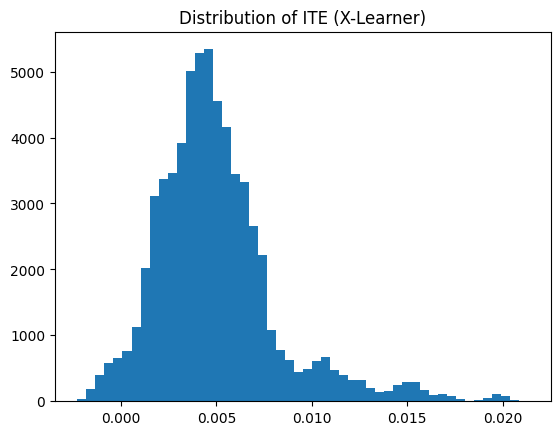

In [61]:
plt.hist(df['ITE_LR'], bins=50)
plt.title("Distribution of ITE (X-Learner)")
plt.show()

In [63]:
print("ATE (T-Learner):", df['ITE_T'].mean())
print("ATE (X-Learner):", df['ITE_LR'].mean())

ATE (T-Learner): 0.005011549758741804
ATE (X-Learner): 0.0049781657240061655


In [64]:
from sklearn.ensemble import RandomForestRegressor

# T-learner models
tau_t_rf = RandomForestRegressor(n_estimators=100, random_state=42)
tau_c_rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit
tau_t_rf.fit(X[T == 1], D1)
tau_c_rf.fit(X[T == 0], D0)

# Predictions
tau_t_pred_rf = tau_t_rf.predict(X)
tau_c_pred_rf = tau_c_rf.predict(X)

# Final ITE
ite_rf = ps * tau_c_pred_rf + (1 - ps) * tau_t_pred_rf

df['ITE_RF'] = ite_rf

In [65]:
df.sort_values(by='ITE_RF', ascending=False).head(10)

,recency,history,mens,womens,newbie,conversion,treatment,history_segment_2) $100 - $200,history_segment_3) $200 - $350,history_segment_4) $350 - $500,history_segment_5) $500 - $750,"history_segment_6) $750 - $1,000","history_segment_7) $1,000 +",zip_code_Surburban,zip_code_Urban,channel_Phone,channel_Web,ITE_T,ITE_LR,ITE_RF
16264,10,169.15,0,1,0,1,1,True,False,False,False,False,False,True,False,False,True,0.006088,0.006050,0.274611
36046,11,37.56,1,0,0,1,1,False,False,False,False,False,False,True,False,False,True,0.004547,0.004385,0.273736
25517,11,37.62,1,0,0,0,0,False,False,False,False,False,False,True,False,False,True,0.004547,0.004385,0.267053
60802,9,127.99,1,0,0,1,1,True,False,False,False,False,False,True,False,True,False,0.002853,0.002126,0.266398
24991,1,646.37,1,1,1,1,1,False,False,False,True,False,False,False,True,False,False,0.017342,0.014581,0.261466
53958,10,37.60,1,0,0,1,1,False,False,False,False,False,False,True,False,False,True,0.004552,0.004281,0.260958
52116,6,177.30,1,0,0,1,1,True,False,False,False,False,False,True,False,True,False,0.002477,0.001523,0.256784
16530,7,287.52,1,1,0,1,1,False,True,False,False,False,False,False,True,True,False,0.006236,0.006544,0.255249
33510,3,125.78,0,1,0,1,1,True,False,False,False,False,False,False,True,True,False,0.004218,0.003949,0.253424
55044,1,774.14,1,1,1,1,1,False,False,False,False,True,False,False,True,False,False,0.023484,0.020127,0.251005


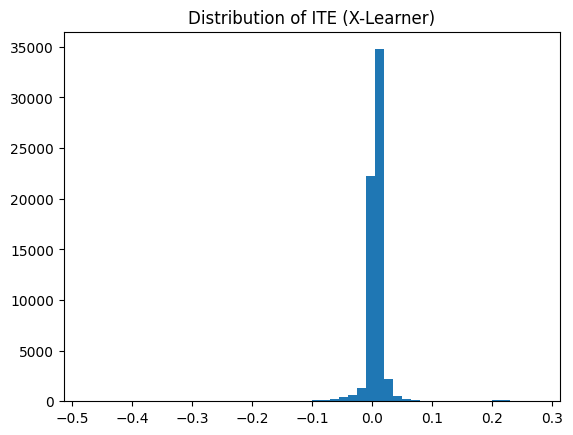

In [66]:
plt.hist(df['ITE_RF'], bins=50)
plt.title("Distribution of ITE (X-Learner)")
plt.show()

In [67]:
mu1 = tau_t_rf.predict(X)
mu0 = tau_c_rf.predict(X)

tau = mu1 - mu0

In [69]:
print("ATE (T-Learner):", df['ITE_T'].mean())
print("ATE (X-Learner):", df['ITE_RF'].mean())

ATE (T-Learner): 0.005011549758741804
ATE (X-Learner): 0.004869245617777473


In [ ]:
%pip install econml

In [ ]:

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Use existing variables
# X, T, Y already defined

ModuleNotFoundError: No module named 'econml'